# 00 Â· Exploratory data analysis: training images and segmentation front-ends

This notebook looks at the 2D data the models learn from, **before** any GAN is trained:

1. the MicroLib 000210 micrograph, its gray-level histogram, the Otsu threshold and the curated MicroLib phase levels;
2. **Otsu vs SAM** on MicroLib: side by side, where they disagree, phase fraction and IoU/Dice against the annotation-derived reference;
3. the same comparison on the **synthetic** image, where a true ground truth exists;
4. the 64Ã—64 training crops: gallery and per-crop phase-fraction spread (why evaluation needs many seeds);
5. 2D descriptors Sâ‚‚(r) and L(r) of the Otsu, SAM and reference maps, and x vs y isotropy of the training image;
6. the random-structure floor (what a model that only matches Ï† would score).

It only reads files produced by `make data` and `make sam` (both datasets); it trains nothing and runs on CPU in about a minute.

In [1]:
import os
from pathlib import Path

# run from the repository root whether the notebook is opened from notebooks/ or from the root
if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from matplotlib.colors import ListedColormap
from PIL import Image
from scipy.ndimage import binary_dilation

from src.data.make_dataset import binarize
from src.features.descriptors import lineal_path, lineal_path_axis, s2_map, s2_radial, s2_mae, relative_error
from src.features.sam_segment import annotation_reference, iou_dice
from src.models.slicegan_wrapper import load_label_map
from src.utils import load_config

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 10, "axes.labelsize": 9, "legend.frameon": False})
COLORS = {"Otsu": "#2a6fdb", "SAM": "#d9822b", "reference": "#3a3a3a"}  # fixed per method in every figure
RMAX = 32

## 1 Â· The MicroLib 000210 micrograph

image 800x437 px, pixel 0.687 um -> 550 x 300 um
Otsu threshold 79.2 | MicroLib levels [8, 133] -> midpoint 70.5


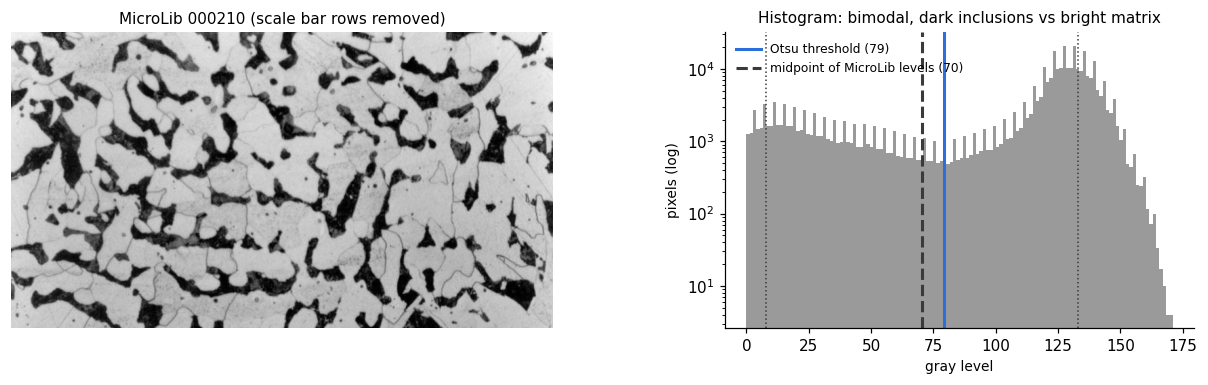

In [2]:
cfg = load_config("configs/m3_swin_sam.yaml", ["configs/data/microlib_000210.yaml"])
ml = cfg["data"]["microlib"]
raw8 = np.asarray(Image.open(cfg["data"]["raw_path"]).convert("L")).astype(np.float32)   # cropped, 8-bit
otsu = load_label_map(Path(cfg["data"]["train_dirs"]["raw"]) / "image.png")
sam = load_label_map(Path(cfg["data"]["train_dirs"]["sam"]) / "image.png")
ref = annotation_reference(cfg)
meta_otsu = yaml.safe_load(Path(cfg["data"]["train_dirs"]["raw"], "meta.yaml").read_text(encoding="utf-8"))
meta_sam = yaml.safe_load(Path(cfg["data"]["train_dirs"]["sam"], "meta.yaml").read_text(encoding="utf-8"))

lo, hi = raw8.min(), raw8.max()
t_otsu = lo + meta_otsu["otsu_threshold"] * (hi - lo)       # Otsu threshold back on the 8-bit scale
t_ref = float(np.mean(ml["phases_gray"]))                   # midpoint of the curated MicroLib levels
print(f"image {raw8.shape[1]}x{raw8.shape[0]} px, pixel {ml['pixel_size_um']} um "
      f"-> {raw8.shape[1] * ml['pixel_size_um']:.0f} x {raw8.shape[0] * ml['pixel_size_um']:.0f} um")
print(f"Otsu threshold {t_otsu:.1f} | MicroLib levels {ml['phases_gray']} -> midpoint {t_ref:.1f}")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 3.6), gridspec_kw={"width_ratios": [1.6, 1]})
a0.imshow(raw8, cmap="gray"); a0.set_title("MicroLib 000210 (scale bar rows removed)"); a0.axis("off")
a1.hist(raw8.ravel(), bins=128, color="#9a9a9a", log=True)
a1.axvline(t_otsu, color=COLORS["Otsu"], lw=2, label=f"Otsu threshold ({t_otsu:.0f})")
a1.axvline(t_ref, color=COLORS["reference"], lw=2, ls="--", label=f"midpoint of MicroLib levels ({t_ref:.0f})")
for g in ml["phases_gray"]:
    a1.axvline(g, color=COLORS["reference"], lw=1, ls=":")
a1.set_xlabel("gray level"); a1.set_ylabel("pixels (log)"); a1.legend(fontsize=8)
a1.set_title("Histogram: bimodal, dark inclusions vs bright matrix")
fig.tight_layout()

The histogram is clearly bimodal, so any reasonable threshold between the two modes gives a similar map.
The Otsu threshold sits a little higher than the midpoint of the curated levels, so Otsu labels slightly more
pixels as inclusion (the dark phase); the difference is confined to the gray halo around each inclusion.

## 2 Â· Otsu vs SAM on MicroLib

In [3]:
def disagreement_map(a, b):
    """0 = both matrix, 1 = both inclusion, 2 = only a, 3 = only b."""
    out = a.astype(np.uint8).copy()
    out[(a == 1) & (b == 0)] = 2
    out[(a == 0) & (b == 1)] = 3
    return out

def boundary_band(labels, width=2):
    """Pixels within `width` px of a phase interface."""
    edge = np.zeros(labels.shape, bool)
    edge[:, 1:] |= labels[:, 1:] != labels[:, :-1]
    edge[1:, :] |= labels[1:, :] != labels[:-1, :]
    return binary_dilation(edge, iterations=width)

DIFF_CMAP = ListedColormap(["#ffffff", "#3a3a3a", COLORS["Otsu"], COLORS["SAM"]])

def compare(maps: dict, reference, ref_name: str) -> pd.DataFrame:
    rows = []
    for name, m in maps.items():
        iou, dice = iou_dice(m, reference)
        rows.append({"map": name, "phi": m.mean(), "phi error vs " + ref_name: m.mean() - reference.mean(),
                     "IoU vs " + ref_name: iou, "Dice vs " + ref_name: dice})
    rows.append({"map": ref_name, "phi": reference.mean()})
    return pd.DataFrame(rows).set_index("map").round(4)

compare({"Otsu": otsu, "SAM": sam}, ref, "reference")

,phi,phi error vs reference,IoU vs reference,Dice vs reference
map,,,,
Otsu,0.2321,0.0137,0.9411,0.9697
SAM,0.2169,-0.0016,0.8451,0.9160
reference,0.2185,NaN,NaN,NaN


Otsu and SAM disagree on 3.8% of the pixels; 68% of those lie within 2 px of an Otsu interface (that band covers 22% of the image).
Otsu-only inclusion pixels 2.7%, SAM-only 1.1%; SAM groups classified: 396 (191 inclusion)


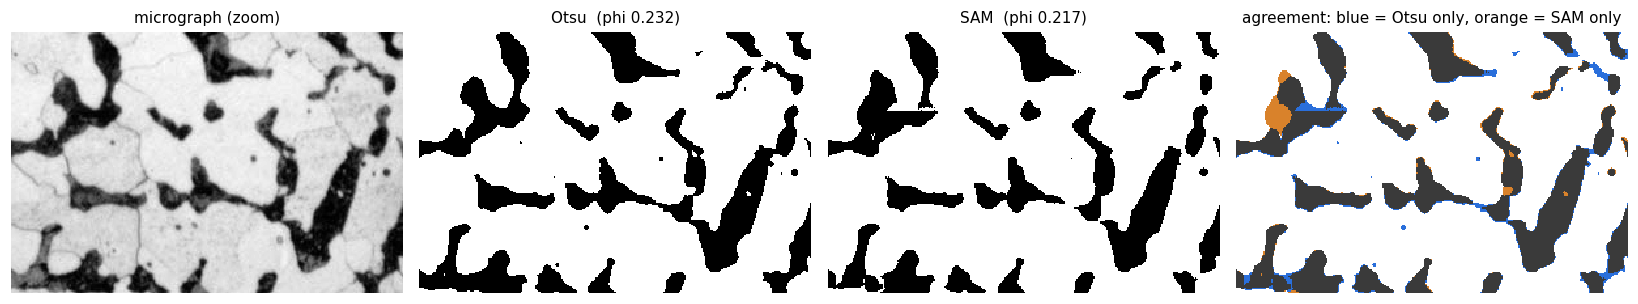

In [4]:
diff = disagreement_map(otsu, sam)
band = boundary_band(otsu, 2)
dis = diff >= 2
print(f"Otsu and SAM disagree on {dis.mean():.1%} of the pixels; "
      f"{(dis & band).sum() / dis.sum():.0%} of those lie within 2 px of an Otsu interface "
      f"(that band covers {band.mean():.0%} of the image).")
print(f"Otsu-only inclusion pixels {np.mean(diff == 2):.1%}, SAM-only {np.mean(diff == 3):.1%}; "
      f"SAM groups classified: {meta_sam['n_groups']} ({meta_sam['n_inclusion_groups']} inclusion)")

win = (slice(120, 320), slice(250, 550))   # zoom window
fig, axes = plt.subplots(1, 4, figsize=(15, 3.3))
for ax, img, title, cm in ((axes[0], raw8[win], "micrograph (zoom)", "gray"),
                           (axes[1], otsu[win], f"Otsu  (phi {otsu.mean():.3f})", "gray_r"),
                           (axes[2], sam[win], f"SAM  (phi {sam.mean():.3f})", "gray_r")):
    ax.imshow(img, cmap=cm, interpolation="nearest"); ax.set_title(title); ax.axis("off")
axes[3].imshow(diff[win], cmap=DIFF_CMAP, vmin=0, vmax=3, interpolation="nearest")
axes[3].set_title("agreement: blue = Otsu only, orange = SAM only"); axes[3].axis("off")
fig.tight_layout()

**Reading.** Both front-ends find the same inclusions and agree on about 96 % of the pixels. Two thirds of the
disagreement is a thin rim along interfaces, where Otsu (threshold 79, above the curated midpoint 70) adds the gray
halo around each dark particle (blue). The remaining third is whole regions: SAM occasionally takes a mid-gray
patch as one object and classifies it as inclusion (the orange blob on the left). Net effect: SAM's Ï† is within
0.002 of the curated reference, Otsu's is 0.014 too high, yet Otsu has the higher IoU/Dice, because the
reference is itself a global threshold (the same kind of rule as Otsu). Neither map is a hand-labelled ground
truth, which is why the synthetic image (next section) is the decisive test.

## 3 Â· Otsu vs SAM on the synthetic image (true ground truth)

,phi,phi error vs ground truth,IoU vs ground truth,Dice vs ground truth
map,,,,
Otsu,0.2540,0.0035,0.9134,0.9547
SAM,0.2898,0.0393,0.8635,0.9268
ground truth,0.2505,NaN,NaN,NaN


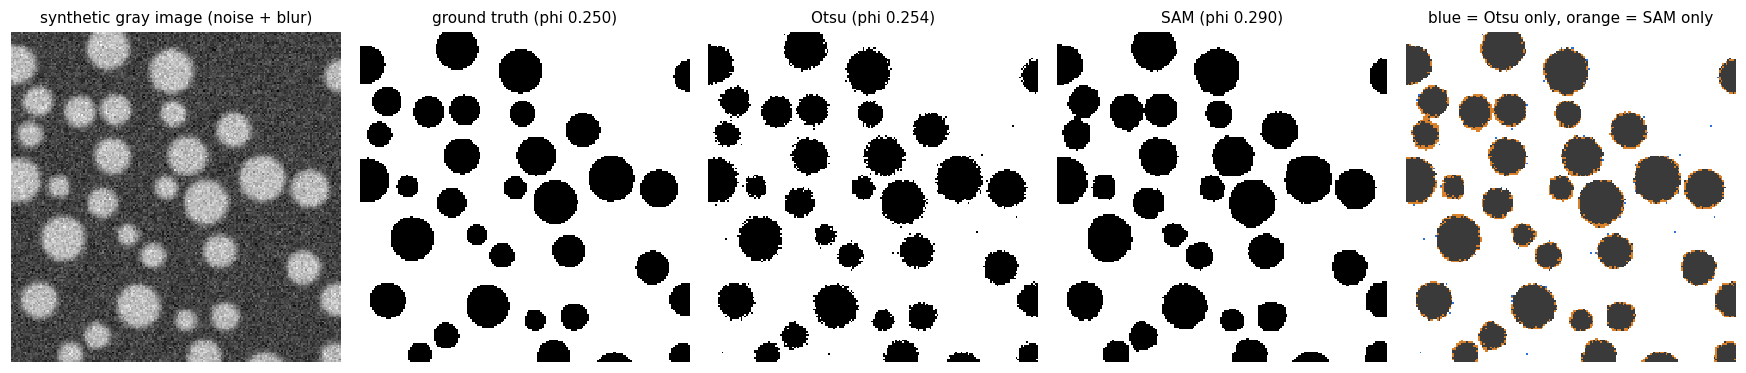

In [5]:
cfg_s = load_config("configs/m3_swin_sam.yaml")
gray_s = np.asarray(Image.open(cfg_s["data"]["raw_path"]).convert("L")).astype(np.float32) / 255
gt_s = load_label_map(Path(cfg_s["data"]["raw_path"]).with_name("micro_2d_gt.png"))
otsu_s = load_label_map(Path(cfg_s["data"]["train_dirs"]["raw"]) / "image.png")
sam_s = load_label_map(Path(cfg_s["data"]["train_dirs"]["sam"]) / "image.png")

diff_s = disagreement_map(otsu_s, sam_s)
fig, axes = plt.subplots(1, 5, figsize=(16, 3.3))
for ax, img, title, cm in ((axes[0], gray_s, "synthetic gray image (noise + blur)", "gray"),
                           (axes[1], gt_s, f"ground truth (phi {gt_s.mean():.3f})", "gray_r"),
                           (axes[2], otsu_s, f"Otsu (phi {otsu_s.mean():.3f})", "gray_r"),
                           (axes[3], sam_s, f"SAM (phi {sam_s.mean():.3f})", "gray_r")):
    ax.imshow(img[:192, :192], cmap=cm, interpolation="nearest"); ax.set_title(title); ax.axis("off")
axes[4].imshow(diff_s[:192, :192], cmap=DIFF_CMAP, vmin=0, vmax=3, interpolation="nearest")
axes[4].set_title("blue = Otsu only, orange = SAM only"); axes[4].axis("off")
fig.tight_layout()

compare({"Otsu": otsu_s, "SAM": sam_s}, gt_s, "ground truth")

In [6]:
# Where are SAM's errors? Split the pixels it gets wrong into "near an interface" and "elsewhere".
for name, m in (("Otsu", otsu_s), ("SAM", sam_s)):
    wrong = m != gt_s
    near = boundary_band(gt_s, 2)
    fp, fn = np.mean((m == 1) & (gt_s == 0)), np.mean((m == 0) & (gt_s == 1))
    print(f"{name:4s}: {wrong.mean():.2%} pixels wrong, {(wrong & near).sum() / wrong.sum():.0%} of them within 2 px "
          f"of a true interface | false inclusion {fp:.2%}, missed inclusion {fn:.2%}")

Otsu: 2.28% pixels wrong, 98% of them within 2 px of a true interface | false inclusion 1.32%, missed inclusion 0.97%
SAM : 3.96% pixels wrong, 100% of them within 2 px of a true interface | false inclusion 3.95%, missed inclusion 0.01%


**Reading.** On the synthetic image the ground truth is known exactly, and Otsu beats SAM. SAM's error is a
systematic dilation: all of its wrong pixels lie within 2 px of a true interface and almost all of them are false
inclusion, i.e. each mask extends about one pixel into the blurred rim, which adds up to Ï† too high by 0.04.
Otsu's errors sit at the same interfaces but are symmetric (false and missed inclusion roughly balance) plus some
isolated noise pixels, so its Ï† is almost exact. This anticipates RQ3: SAM is not a free upgrade over a global
threshold on a clean two-phase image, and M3 inherits SAM's Ï† bias (see report Â§5.4).

## 4 Â· Training crops: what one 64Ã—64 view contains

288 crops (64x64, stride 32); per-crop phi mean 0.237, std 0.097, range 0.010-0.673


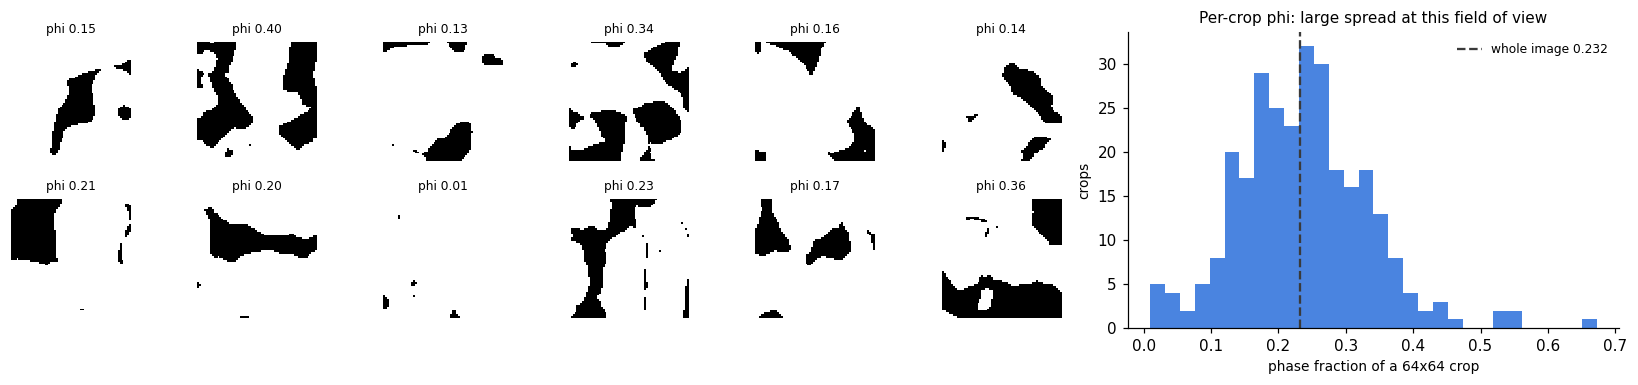

In [7]:
crops = np.load(Path(cfg["data"]["train_dirs"]["raw"]) / "crops.npy")
phis = crops.reshape(len(crops), -1).mean(1)
print(f"{len(crops)} crops (64x64, stride 32); per-crop phi mean {phis.mean():.3f}, std {phis.std():.3f}, "
      f"range {phis.min():.3f}-{phis.max():.3f}")

rng = np.random.default_rng(0)
pick = np.sort(rng.choice(len(crops), 12, replace=False))
fig = plt.figure(figsize=(15, 3.6))
gs = fig.add_gridspec(2, 9)
for k, i in enumerate(pick):
    ax = fig.add_subplot(gs[k // 6, k % 6])
    ax.imshow(crops[i], cmap="gray_r", interpolation="nearest"); ax.axis("off")
    ax.set_title(f"phi {phis[i]:.2f}", fontsize=8)
ax = fig.add_subplot(gs[:, 6:])
ax.hist(phis, bins=30, color=COLORS["Otsu"], alpha=0.85)
ax.axvline(otsu.mean(), color=COLORS["reference"], ls="--", lw=1.5, label=f"whole image {otsu.mean():.3f}")
ax.set_xlabel("phase fraction of a 64x64 crop"); ax.set_ylabel("crops"); ax.legend(fontsize=8)
ax.set_title("Per-crop phi: large spread at this field of view")
fig.tight_layout()

In [8]:
# How many independent 64x64 views are needed to pin phi down? Standard error ~ std / sqrt(n).
for n in (1, 16, 128):
    print(f"n = {n:3d} crops: standard error of mean phi ~ {phis.std() / np.sqrt(n):.4f}")

# One generated 64^3 volume holds 64 slices per axis, but neighbouring slices are strongly correlated, so its
# effective number of independent 64x64 views is far smaller (measured per-volume phi spread: about 0.05).

n =   1 crops: standard error of mean phi ~ 0.0971
n =  16 crops: standard error of mean phi ~ 0.0243
n = 128 crops: standard error of mean phi ~ 0.0086


**Reading.** A 64Ã—64 crop sees only a handful of inclusions, so its Ï† varies by Â±0.10 around the image value.
A 64Â³ volume averages over many slices but stays noisy (about Â±0.05 per volume). This is the reason the
evaluation protocol uses 16 seeds for per-epoch selection, 128 validation seeds for checkpoint choice and
128 test seeds with bootstrap confidence intervals: with a single volume, model differences of 0.01 in Ï†
would be indistinguishable from noise.

## 5 Â· 2D descriptors of the training maps and in-plane isotropy

,S2 MAE vs reference,S2 err vs reference,L MAE vs reference
Otsu,0.0085,0.0933,0.0074
SAM,0.0009,0.0099,0.0012


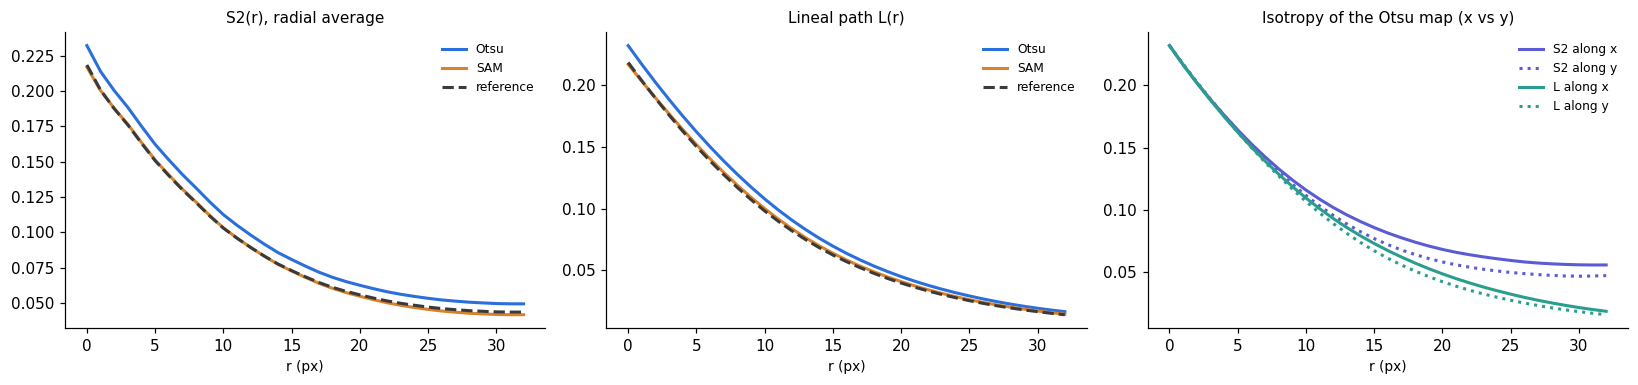

In [9]:
maps = {"Otsu": otsu, "SAM": sam, "reference": ref}
s2 = {k: s2_radial(v, RMAX) for k, v in maps.items()}
lp = {k: lineal_path(v, RMAX) for k, v in maps.items()}

fig, (a0, a1, a2) = plt.subplots(1, 3, figsize=(15, 3.6))
r = np.arange(RMAX + 1)
for k in maps:
    a0.plot(r, s2[k], color=COLORS[k], lw=2, ls="--" if k == "reference" else "-", label=k)
    a1.plot(r, lp[k], color=COLORS[k], lw=2, ls="--" if k == "reference" else "-", label=k)
a0.set_title("S2(r), radial average"); a0.set_xlabel("r (px)"); a0.legend(fontsize=8)
a1.set_title("Lineal path L(r)"); a1.set_xlabel("r (px)"); a1.legend(fontsize=8)

# isotropy: S2 along x (rows) vs along y (columns) for the Otsu map
m = s2_map(otsu)
c0, c1 = m.shape[0] // 2, m.shape[1] // 2
s2x, s2y = m[c0, c1:c1 + RMAX + 1], m[c0:c0 + RMAX + 1, c1]
lx, ly = lineal_path_axis(otsu, RMAX, 1), lineal_path_axis(otsu, RMAX, 0)
a2.plot(r, s2x, color="#5b5bd6", lw=2, label="S2 along x")
a2.plot(r, s2y, color="#5b5bd6", lw=2, ls=":", label="S2 along y")
a2.plot(r, lx, color="#2a9d8f", lw=2, label="L along x")
a2.plot(r, ly, color="#2a9d8f", lw=2, ls=":", label="L along y")
a2.set_title("Isotropy of the Otsu map (x vs y)"); a2.set_xlabel("r (px)"); a2.legend(fontsize=8)
fig.tight_layout()

pd.DataFrame({
    "S2 MAE vs reference": {k: s2_mae(s2[k], s2["reference"]) for k in ("Otsu", "SAM")},
    "S2 err vs reference": {k: relative_error(s2[k], s2["reference"]) for k in ("Otsu", "SAM")},
    "L MAE vs reference": {k: s2_mae(lp[k], lp["reference"]) for k in ("Otsu", "SAM")},
}).round(4)

In [10]:
print(f"x vs y anisotropy of the Otsu map: S2 MAE {s2_mae(s2x, s2y):.4f}, L MAE {s2_mae(lx, ly):.4f}")
# correlation length: first r where S2 falls to within 5 % of its plateau phi^2
phi = otsu.mean()
for name, curve in (("x", s2x), ("y", s2y)):
    target = phi ** 2 + 0.05 * (phi - phi ** 2)
    print(f"S2 along {name} reaches phi^2 + 5 % at r = {int(np.argmax(curve <= target))} px")

x vs y anisotropy of the Otsu map: S2 MAE 0.0065, L MAE 0.0036
S2 along x reaches phi^2 + 5 % at r = 23 px
S2 along y reaches phi^2 + 5 % at r = 19 px


**Reading.** The SAM curves lie on top of the reference curves, while Otsu's are shifted up by its Ï† excess
(Sâ‚‚(0) = Ï†, and the offset persists at all r). So the choice of front-end changes the *target* the GAN is asked
to match by about 0.009 in Sâ‚‚ MAE, which is larger than the gap between the best MicroLib models (0.001-0.003).
This is why the report scores every model against its own training map and, separately, against a common
reference.

The training image is **mildly anisotropic**: the micrograph shows banding along x (elongated dark regions),
so Sâ‚‚ and L decay more slowly along x (correlation length about 23 px vs 19 px along y; the x vs y Sâ‚‚ MAE is
0.0065). SliceGAN assumes the same statistics on all three orthogonal planes, and the D4 augmentation used here
(random 90Â° rotations and flips of the crops) symmetrizes x and y on purpose, so the generators learn an isotropic
version of this structure. The radially averaged metrics in the report are insensitive to this, but no model
here can reproduce the banding direction. Finally, a correlation length of about 20 px means one 64 px crop spans
only about three correlation lengths, consistent with the large per-crop Ï† spread above.

## 6 Â· The random-structure floor

In [11]:
# A structure that matches phi and nothing else: i.i.d. Bernoulli pixels with the training phi.
rng = np.random.default_rng(0)
rand = (rng.random((64, 64, 64)) < phi).astype(np.uint8)
s2_rand = s2_radial(rand, RMAX).mean(0)
l_rand = lineal_path(rand, RMAX)
s2_train = s2_radial(crops, RMAX).mean(0)
l_train = lineal_path(crops, RMAX)
print(f"2D random floor vs training crops: S2 MAE {s2_mae(s2_rand, s2_train):.4f} "
      f"(err {relative_error(s2_rand, s2_train):.2f}), L MAE {s2_mae(l_rand, l_train):.4f} "
      f"(err {relative_error(l_rand, l_train):.2f})")

2D random floor vs training crops: S2 MAE 0.0431 (err 0.42), L MAE 0.0789 (err 0.90)


A model that only reproduces the phase fraction scores an Sâ‚‚ MAE of about 0.04, the same order as the 3D
random-volume floor in the report (0.042). Every trained model in the report sits one order of magnitude
below it (0.001-0.008 on MicroLib), so the descriptor gaps between models are small differences between good
generators, not the difference between structure and noise.

## Summary

| Question | Finding |
|---|---|
| Is the MicroLib image easy to segment? | Yes: bimodal histogram; Otsu and SAM agree on about 96 % of pixels, two thirds of the disagreement on interface rims. |
| Otsu vs SAM on MicroLib | SAM is closer to the curated reference in Ï†, Sâ‚‚ and L; Otsu is closer pixel by pixel (the reference is a global threshold too). |
| Otsu vs SAM with a true ground truth (synthetic) | Otsu wins: SAM dilates every inclusion by about 1 px (Ï† too high by 0.04, IoU 0.86 vs 0.91). |
| Does the front-end matter for the GAN target? | Yes: Otsu vs SAM shifts Sâ‚‚ by 0.009 MAE, more than the gap between the best models. |
| Why so many evaluation seeds? | A 64Ã—64 crop varies by Â±0.10 in Ï† and a 64Â³ volume by about Â±0.05; 128 test seeds and bootstrap CIs are needed to separate models. |
| Is the training image isotropic in-plane? | Mildly not: banding along x (correlation length 23 vs 19 px). D4 augmentation makes the generators isotropic by design. |
| What does "good" mean numerically? | The Ï†-only random floor is Sâ‚‚ MAE about 0.04; trained models reach 0.001-0.008. |